# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [60]:
import pandas as pd

Load our cleaned DataFrames

In [61]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1Tla62vfu__kCqvgypZyVt2S9VuC016yH/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1OhtkQS2fwOYdzfd-qPh7im35iLc-L9TA/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

## 1.&nbsp; Define Pandas display format

In [62]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
products_qu = products_cl.copy()

In [63]:
pd.get_option('display.max_rows')

1000

In [64]:
pd.describe_option('display.max_rows')

display.max_rows : int
    If max_rows is exceeded, switch to truncate view. Depending on
    `large_repr`, objects are either centrally truncated or printed as
    a summary view. 'None' value means unlimited.

    In case python/IPython is running in a terminal and `large_repr`
    equals 'truncate' this can be set to 0 and pandas will auto-detect
    the height of the terminal and print a truncated object which fits
    the screen height. The IPython notebook, IPython qtconsole, or
    IDLE do not run in a terminal and hence it is not possible to do
    correct auto-detection.
    [default: 60] [currently: 1000]


In [65]:
pd.set_option('display.float_format', lambda x: '%.2f'%x)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth',None)

## 2.&nbsp; Exclude unwanted orders

In [66]:
orders_qu.head()

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled


In [67]:
orders_qu.shape

(226904, 4)

In [68]:
orders_qu.state.value_counts()

,count
state,
Shopping Basket,117809
Completed,46605
Place Order,40883
Pending,14374
Cancelled,7233


In [69]:
#keep only completed orders
orders_qu =orders_qu.loc[orders_qu.state == 'Completed', :]

In [70]:
orders_qu.shape

(46605, 4)

In [71]:
orders_qu.order_id.nunique()

46605

In [72]:
orderlines_qu.id_order.nunique()

170213

In [73]:
orders_orderlines = orders_qu.merge(orderlines_qu, how= 'inner', left_on ='order_id', right_on='id_order')

In [74]:
orders_orderlines['order_id'].nunique()

43064

In [75]:
#order_ids that are in both tables
order_ids = orders_orderlines['order_id'].unique()

In [76]:
order_ids

array([241423, 242832, 243330, ..., 527074, 527096, 527112])

In [77]:
#keep those ids in orders
orders_qu = orders_qu.loc[orders_qu['order_id'].isin(order_ids),: ]

#keep those ids in orderlines
orderlines_qu = orderlines_qu.loc[orderlines_qu['id_order'].isin(order_ids), :]

In [78]:
# they should both contain the same numver os unique
orders_qu['order_id'].nunique(), orderlines_qu['id_order'].nunique()

(43064, 43064)

## 3.&nbsp; Excluding orders with unknown products


In [79]:
orderlines_products = orderlines_qu.merge(products_qu, how='left', on = 'sku')[['id_order','sku','name']]

In [80]:
orderlines_products.sample(10)

,id_order,sku,name
35659,442904,WDT0141,"WD Red 3TB 35 ""Mac PC hard drive and NAS"
53836,514597,STM0038,"STM Bags Small Alley Backpack MacBook Pro 13 ""black coal"
21610,390245,BEL0300,Belkin Rockstar Lightning Audio Adapter + Charging for iPhone White 7
29480,420536,APP0474,"Apple 60W MagSafe 2 charger MacBook Pro Retina Display 13 """
16670,373952,APP1970,Apple iPhone 32GB Space Gray
29842,421886,PLA0027,Plantronics BackBeat Fit Wireless Headphones Black
7929,323377,APP0280,Apple HDMI to HDMI Cable 1.8m
22416,393196,PAC0653,Samsung SSD 850 expansion kit EVO 250GB + Datadoubler for MacBook / MacBook Pro 2008-2012
1965,306054,APP0697,OEM USB Cable for iPhone iPad Dock and Apple iPod White Compatible
38909,455312,GRT0420,Griffin Survivor Case Tough Summit iPhone 6 / 6S Rosa


In [81]:
#counting how many missing product we have
orderlines_products.name.isna().value_counts()

,count
name,
False,55320
True,1394


In [82]:
#we will remove the entire ordr that contains an unknown product
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), 'id_order'].unique()
orders_to_delete

array([299638, 299706, 299712, ..., 526106, 526122, 526363])

In [83]:
#keep only orders in in orders and orderlines ,that are not in this list of corrupted orders
orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete), :]

In [84]:
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete), :]

In [85]:
#check ti make sure we are filtering both dataframes the same
orders_qu['order_id'].nunique(), orderlines_qu['id_order'].nunique()

(41701, 41701)

## 4.&nbsp; Explore the revenue from different tables

In [86]:
orderlines_qu_copy = orderlines_qu.copy()

In [87]:
orders_qu_copy = orders_qu.copy()

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [88]:
orderlines_qu_copy['unit_price_total']= orderlines_qu_copy['product_quantity']* orderlines_qu_copy['unit_price']

In [89]:
orderlines_qu_copy.tail(10)

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
215873,1649440,527035,0,1,APP0498,23.00,2018-03-14 11:41:55,23.00
215874,1649441,527034,0,1,APP0927,13.99,2018-03-14 11:42:01,13.99
215876,1649446,527042,0,1,APP0927,13.99,2018-03-14 11:42:38,13.99
215877,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,9.99
215886,1649468,525664,0,1,TUC0336,7.93,2018-03-14 11:43:59,7.93
215889,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
215906,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98
215911,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98
215932,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97
215949,1649593,527112,0,1,APP0698,9.99,2018-03-14 11:58:13,9.99


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [90]:
orderlines_order_ids = orderlines_qu_copy.groupby('id_order', as_index= False)['unit_price_total'].sum()

In [91]:
orderlines_order_ids

,id_order,unit_price_total
0,241423,129.16
1,242832,10.77
2,243330,77.99
3,245275,149.00
4,245595,105.98
...,...,...
41696,527042,13.99
41697,527070,19.98
41698,527074,19.98
41699,527096,29.97


### What is the average difference between `total_paid` and `unit_price_total`?

In [92]:
diff_df = orders_qu_copy.merge(orderlines_order_ids, left_on='order_id', right_on='id_order')

In [93]:
# your code here

In [94]:
diff_df['difference'] = diff_df['total_paid'] - diff_df['unit_price_total']
diff_df.head(10)

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
5,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
6,247524,2018-01-09 14:21:34,167.98,Completed,247524,162.99,4.99
7,247643,2017-05-26 11:50:35,153.54,Completed,247643,153.54,0.00
8,250275,2017-11-19 22:34:54,54.99,Completed,250275,51.00,3.99
9,251302,2017-05-10 12:27:33,140.99,Completed,251302,140.99,0.00


In [95]:
diff_df.difference.mean().round(2)

np.float64(4.47)

### What is the distribution of these differences?

(<Axes: >,)

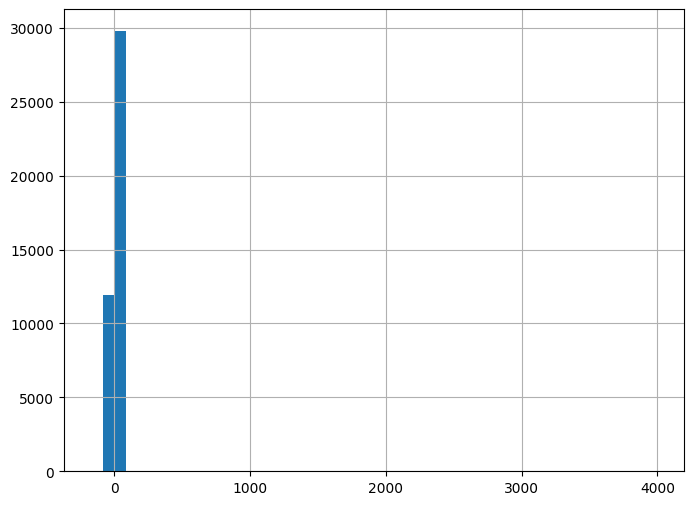

In [96]:
diff_df.difference.hist(bins=50, figsize=(8,6)),

In [97]:
diff_df.difference.describe()

,difference
count,41701.00
mean,4.47
std,26.05
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,3984.99


### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

In [98]:
#discount,seasonal discounts , gift cards, vouvher , experess postage

### If there are differences that you can’t explain: what should you do with these orders?

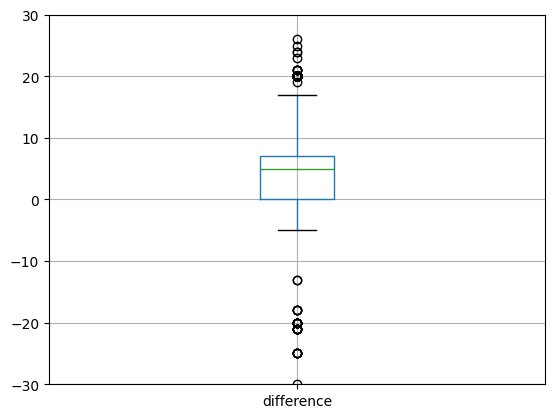

In [99]:
#we know this rule from gthe boxplot
import matplotlib.pyplot as plt

ax = diff_df.boxplot('difference');
ax.set_ylim(-30, +30)
plt.show()

In [100]:
#calculate the quartiles
Q1 = diff_df['difference'].quantile(0.25)
Q3 = diff_df['difference'].quantile(0.75)

Q1 , Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [101]:
#calculate the interquartile range
IQR = Q3-Q1
IQR

np.float64(6.989999999999981)

In [102]:
# lower boundry
Q1 -1.5*IQR

np.float64(-10.484999999999971)

In [103]:
# upper boundry
Q3 + 1.5*IQR

np.float64(17.47499999999995)

In [105]:

# filter the dataframe. to include only 'non_outliers'
diff_no_outliers_df = diff_df.loc[
    (diff_df['difference']>= (Q1 - 1.5*IQR))
    &
    (diff_df['difference']<= (Q3 + 1.5*IQR))
    ,
    :]

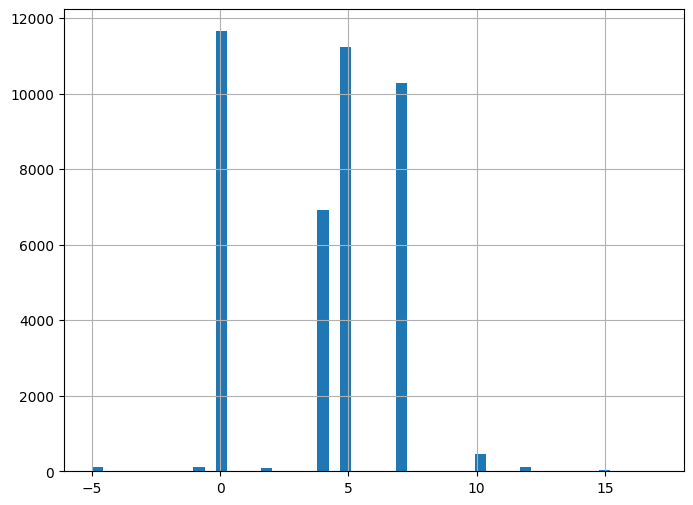

In [106]:
diff_no_outliers_df.difference.hist(bins = 50, figsize= (8,6));

<Axes: >

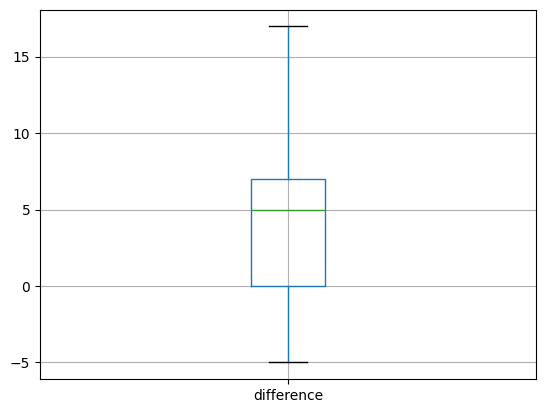

In [112]:
diff_no_outliers_df.boxplot('difference')

In [113]:
diff_no_outliers_df.difference.describe()

,difference
count,40985.00
mean,3.94
std,2.83
min,-5.00
25%,0.00
50%,4.99
75%,6.99
max,16.97


In [114]:
diff_no_outliers_df.difference.value_counts().sort_values(ascending = False).head(10)

,count
difference,
0.00,10476
6.99,4559
4.99,3419
4.99,2523
4.99,2351
6.99,1889
3.99,1882
3.99,1620
3.99,1463


In [117]:
normal_diff_list = diff_no_outliers_df['order_id']

In [118]:
orders_qu = orders_qu.loc[orders_qu['order_id'].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu['id_order'].isin(normal_diff_list), :]

In [119]:
orders_qu['order_id'].nunique(), orderlines_qu['id_order'].nunique()

(40985, 40985)

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

In [ ]:
# your thoughts & code here

Do not forget to download your quality controlled DataFrames

In [ ]:
from google.colab import files

#orders_quality_controlled.to_csv("orders_qu.csv", index=False)
#files.download("orders_qu.csv")

#orderlines_quality_controlled.to_csv("orderlines_qu.csv", index=False)
#files.download("orderlines_qu.csv")